# 📚 02. Linear and Logistic Regression

Welcome to the **Linear and Logistic Regression** tutorial! These are the absolute core baseline algorithms in supervised learning. A deep mathematical and practical understanding of regression and classification is essential for any machine learning journey.

--- 

## 🎯 Tutorial Objectives
In this notebook, we will explore:
1. **Simple Linear Regression**: Theory of Ordinary Least Squares (OLS), fitting lines, and standard evaluation metrics ($R^2$, MSE, MAE).
2. **Multiple Linear Regression & Assumptions**: Multi-feature regression and diagnostic plotting to check standard Gauss-Markov assumptions.
3. **Regularized Regressors (Ridge, Lasso, ElasticNet)**: Understanding the bias-variance trade-off, L1 vs. L2 regularization, and feature selection.
4. **Logistic Regression**: Formulating probability mapping with the Sigmoid function, Log Loss, and evaluating binary classification (Confusion Matrix, Precision/Recall, ROC-AUC).
5. **Multiclass & Decision Boundaries**: Understanding OvR/OvO and plotting probabilistic classification boundaries.

--- 
## 1. Simple Linear Regression

**Simple Linear Regression** models the relationship between a single independent variable $X$ (the predictor) and a continuous dependent variable $y$ (the target) using a straight line.

### 📐 Mathematical Formulation

The linear regression model is expressed as:
$$ y = \beta_0 + \beta_1 x + \epsilon $$

Where:
*   $y$ is the actual target value.
*   $x$ is the input feature.
*   $\beta_0$ is the **y-intercept** (the value of $y$ when $x=0$).
*   $\beta_1$ is the **slope** (the change in $y$ for a one-unit change in $x$).
*   $\epsilon$ represents the random **error term** (residuals/noise).

### 🎯 Cost Function: Mean Squared Error (MSE)
To find the optimal line, we need to minimize the difference between our predicted values $h_\beta(x^{(i)})$ and actual values $y^{(i)}$. We define our **Cost Function** using **Mean Squared Error (MSE)**:

$$ J(\beta_0, \beta_1) = \frac{1}{2m} \sum_{i=1}^m \left(h_\beta(x^{(i)}) - y^{(i)}\right)^2 $$

Where $m$ is the number of training samples, and $h_\beta(x) = \beta_0 + \beta_1 x$.

This optimization technique is known as **Ordinary Least Squares (OLS)**. Let's see this in action by generating some synthetic housing data!

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.datasets import load_breast_cancer, make_regression
import statsmodels.api as sm
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Generate synthetic house price dataset: size (sqft) vs price
X_simple = np.random.normal(1600, 300, 100) # average size 1600 sqft
# Price = 120 * size + 35000 + random noise
noise = np.random.normal(0, 15000, 100)
y_simple = 120 * X_simple + 35000 + noise

# Reshape to 2D array for scikit-learn
X_simple = X_simple.reshape(-1, 1)

# 2. Fit Simple Linear Regression using OLS
ols_simple = LinearRegression()
ols_simple.fit(X_simple, y_simple)

# Retrieve parameters
beta_0 = ols_simple.intercept_
beta_1 = ols_simple.coef_[0]

print(f"Intercept (beta_0): {beta_0:.2f}")
print(f"Slope/Weight (beta_1): {beta_1:.4f}")

Intercept (beta_0): 46571.99
Slope/Weight (beta_1): 112.8371


### 📈 Visualizing the OLS Regression Line

Let's plot the actual data points along with the OLS predicted regression line to visualize the fit.

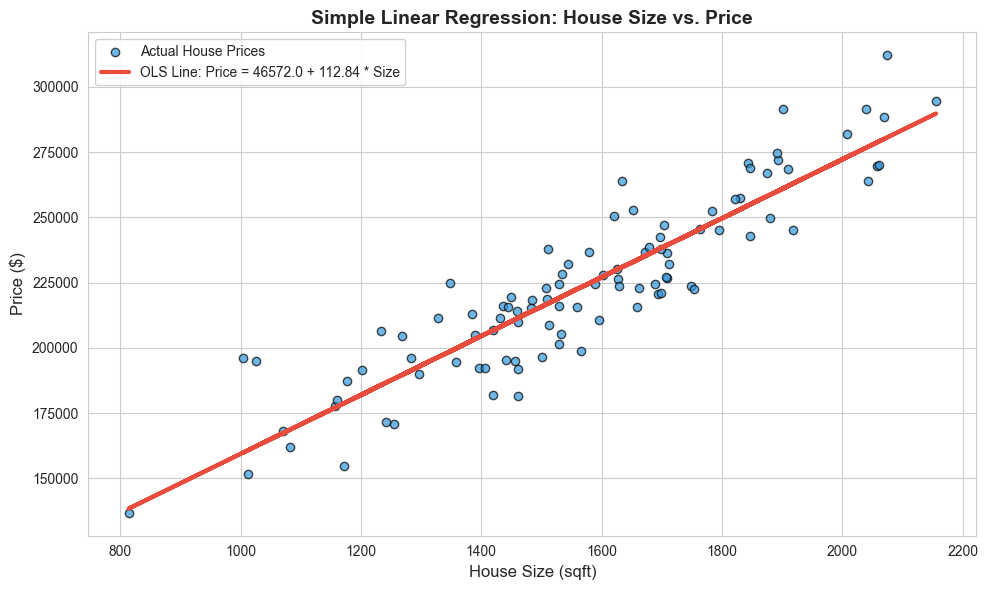

In [3]:
# Generate OLS predictions
y_pred_simple = ols_simple.predict(X_simple)

# Plot actual vs predicted line
plt.scatter(X_simple, y_simple, color='#3498db', alpha=0.7, edgecolors='k', label='Actual House Prices')
plt.plot(X_simple, y_pred_simple, color='#e74c3c', linewidth=3, 
         label=f'OLS Line: Price = {beta_0:.1f} + {beta_1:.2f} * Size')
plt.xlabel('House Size (sqft)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Simple Linear Regression: House Size vs. Price', fontsize=14, fontweight='bold')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

### 📏 Regression Metrics Evaluation
To quantify model performance, we look at three fundamental metrics:
1. **Mean Squared Error (MSE)**: Measures average squared difference between actual and predicted targets. Penalizes large errors heavily.
2. **Mean Absolute Error (MAE)**: Measures average absolute difference. Robust to outlier noise.
3. **R-squared ($R^2$) Score**: The coefficient of determination. Represents the proportion of variance in the target variable that is explained by our independent variable(s).

In [4]:
mse = mean_squared_error(y_simple, y_pred_simple)
mae = mean_absolute_error(y_simple, y_pred_simple)
r2 = r2_score(y_simple, y_pred_simple)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"R-squared (R2) Score:     {r2:.4f} ({r2*100:.1f}% variance explained)")

Mean Squared Error (MSE): 198,817,308.52
Mean Absolute Error (MAE): 11,243.69
R-squared (R2) Score:     0.8247 (82.5% variance explained)


--- 
## 2. Multiple Linear Regression & Assumptions

**Multiple Linear Regression** generalizes the model to multiple predictors:
$$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon $$

### 🚨 Core Assumptions of OLS
For the OLS estimator to be the Best Linear Unbiased Estimator (**BLUE**), several conditions must hold. We can inspect these visually using **diagnostic plotting**:

1.  **Linearity**: The relationship between target and features is linear. (Checked with Residuals vs. Fitted plot: should show no curved pattern).
2.  **Independence (No Multicollinearity)**: Predictors should not be highly correlated. We check this with a **Correlation Heatmap** and **Variance Inflation Factor (VIF)**.
3.  **Homoscedasticity**: Constant variance of residuals across all fitted values. (Checked with Residuals vs. Fitted plot: scatter spread should be uniform).
4.  **Normality of Residuals**: The errors $\epsilon$ are normally distributed. (Checked with **Normal Q-Q Plot** and Residual histogram).

In [5]:
# Generate multiple feature dataset
size = np.random.normal(1800, 400, 200)
bedrooms = np.random.randint(1, 6, 200)
age = np.random.uniform(0, 50, 200)

# Price depends on all three + noise
price = 100 * size + 20000 * bedrooms - 1500 * age + 40000 + np.random.normal(0, 15000, 200)

df_multiple = pd.DataFrame({
    'Size': size,
    'Bedrooms': bedrooms,
    'Age': age,
    'Price': price
})

X_multiple = df_multiple[['Size', 'Bedrooms', 'Age']]
y_multiple = df_multiple['Price']

# Fit statsmodels OLS model for descriptive statistics summary
X_multi_const = sm.add_constant(X_multiple)
model_sm = sm.OLS(y_multiple, X_multi_const).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     795.1
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.06e-109
Time:                        18:01:44   Log-Likelihood:                -2213.4
No. Observations:                 200   AIC:                             4435.
Df Residuals:                     196   BIC:                             4448.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.011e+04   6290.300      6.377      0.0

### 📊 Diagnostic Plots
Let's construct standard regression diagnostic plots to check our assumptions.

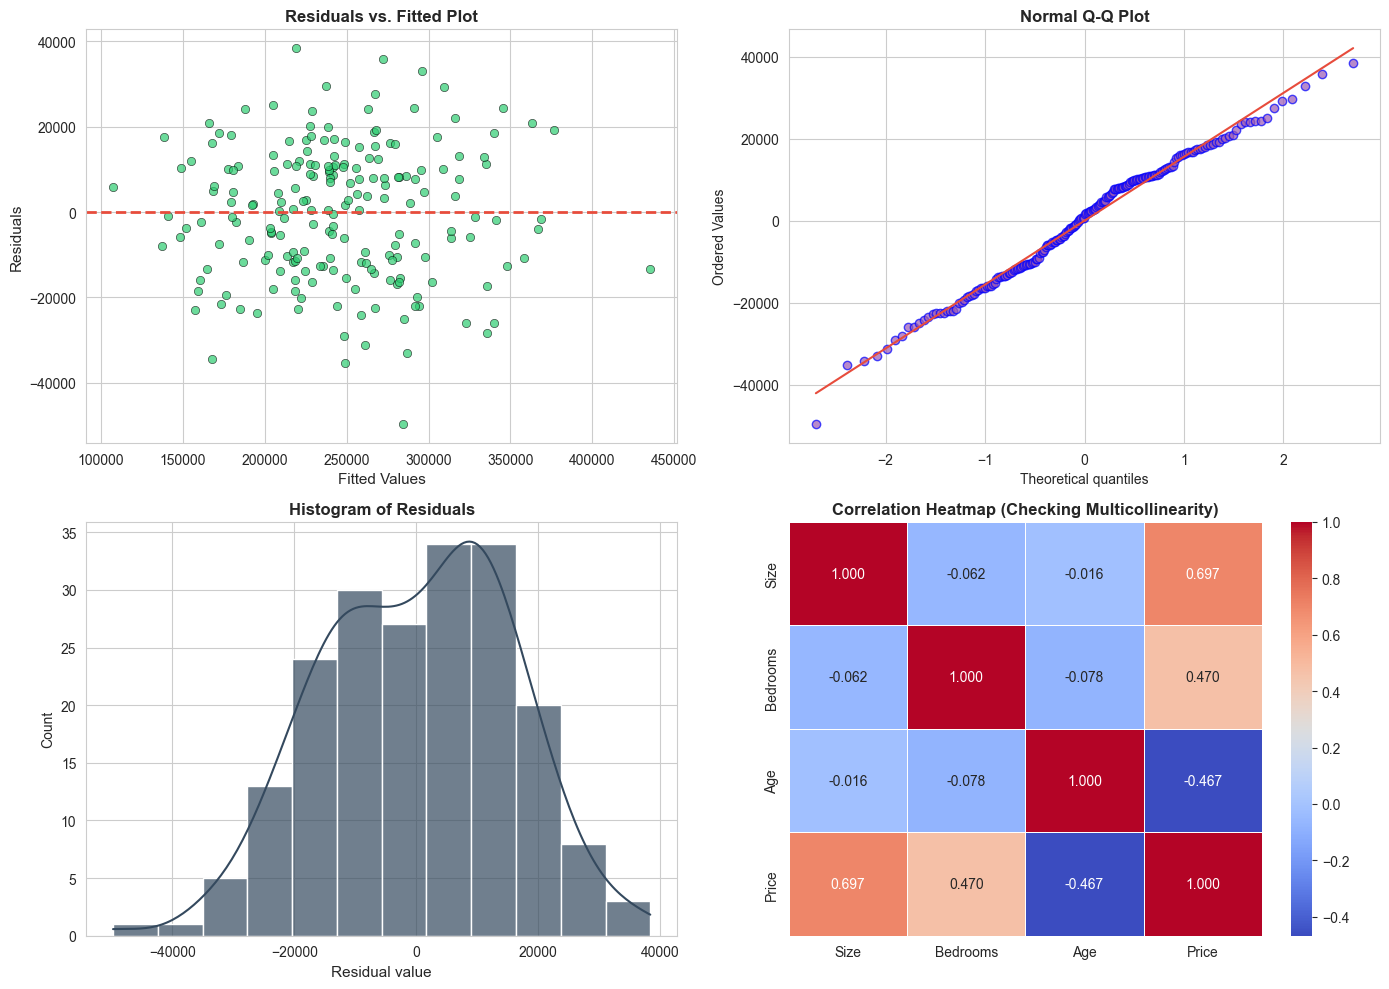

In [6]:
# Calculate residuals and fitted values
residuals = model_sm.resid
fitted_values = model_sm.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs. Fitted (Checking Linearity & Homoscedasticity)
sns.scatterplot(x=fitted_values, y=residuals, color='#2ecc71', alpha=0.7, edgecolors='k', ax=axes[0, 0])
axes[0, 0].axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residuals vs. Fitted Plot', fontsize=12, fontweight='bold')

# 2. Normal Q-Q Plot (Checking Normality of Residuals)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].get_lines()[0].set_markerfacecolor('#9b59b6')
axes[0, 1].get_lines()[0].set_alpha(0.7)
axes[0, 1].get_lines()[1].set_color('#e74c3c')
axes[0, 1].set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')

# 3. Distribution of Residuals
sns.histplot(residuals, kde=True, color='#34495e', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_xlabel('Residual value', fontsize=11)
axes[1, 0].set_title('Histogram of Residuals', fontsize=12, fontweight='bold')

# 4. Correlation Matrix Heatmap
sns.heatmap(df_multiple.corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap (Checking Multicollinearity)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 🔢 Checking Variance Inflation Factor (VIF)
The **VIF** measures how much the variance of an estimated regression coefficient is increased because of multicollinearity. A VIF value greater than 5 or 10 indicates high multicollinearity, which warrants feature correction.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = X_multiple.columns
vif_df["VIF"] = [variance_inflation_factor(X_multiple.values, i) for i in range(len(X_multiple.columns))]
print("VIF Summary Table:")
print(vif_df.to_string(index=False))

VIF Summary Table:
 Feature      VIF
    Size 6.283199
Bedrooms 4.339179
     Age 3.481167


--- 
## 3. Regularized Regressors (Ridge, Lasso, ElasticNet)

When model features are numerous or highly correlated, OLS estimates exhibit **high variance** and easily **overfit** to random noise in the training set.

**Regularization** introduces a penalty term directly into the cost function to control coefficient magnitudes (shrinking them toward zero).

### 🛡️ Regularization Penalties

1. **Ridge Regression ($L_2$ Regularization)**: Adds squared weight penalty:
   $$ J_R(\beta) = \text{MSE} + \alpha \sum_{j=1}^n \beta_j^2 $$
   *Shrinks coefficients evenly, but does not drive them to absolute zero. Ideal for high multicollinearity.*

2. **Lasso Regression ($L_1$ Regularization)**: Adds absolute weight penalty:
   $$ J_L(\beta) = \text{MSE} + \alpha \sum_{j=1}^n |\beta_j| $$
   *Shrinks coefficients to exactly zero. Performs automated **Feature Selection**.* 

3. **ElasticNet**: Blends both $L_1$ and $L_2$ regularization:
   $$ J_{EN}(\beta) = \text{MSE} + \alpha \rho \sum_{j=1}^n |\beta_j| + \frac{\alpha(1-\rho)}{2} \sum_{j=1}^n \beta_j^2 $$
   *Useful when multiple features are highly correlated; groups them together.*

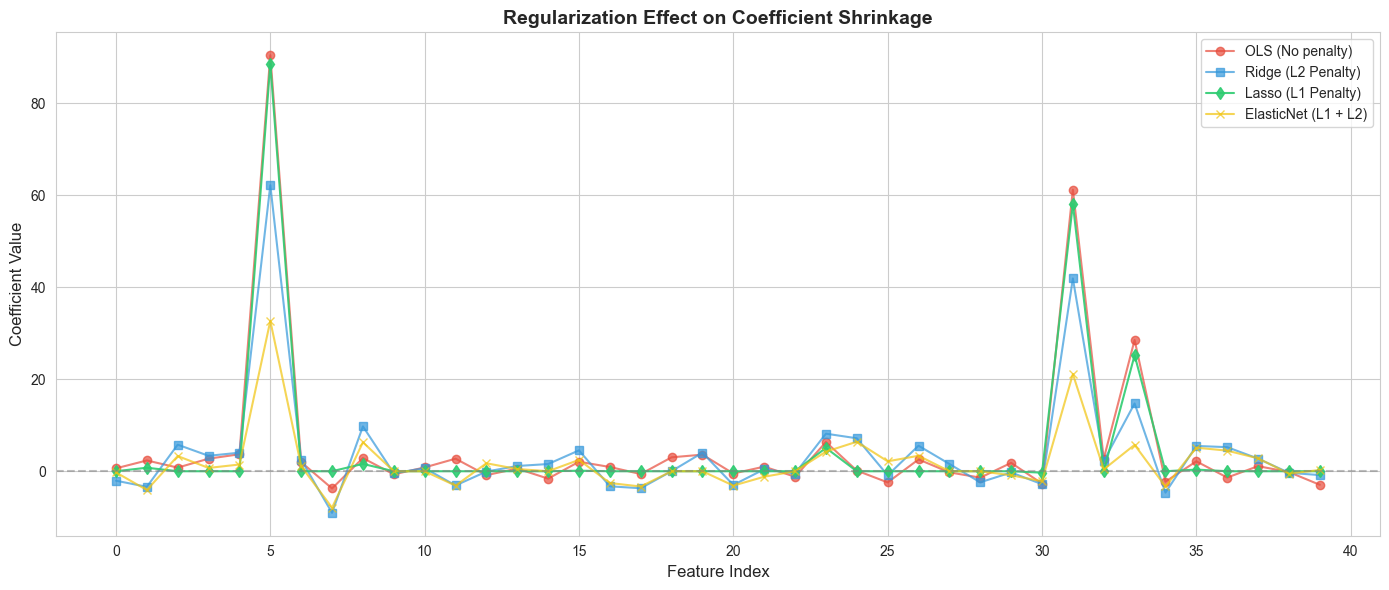

In [8]:
# Generate highly multicollinear/noisy dataset: 60 samples, 40 features, but only 5 are informative
X_noisy, y_noisy, coef_true = make_regression(
    n_samples=60,
    n_features=40,
    n_informative=5,
    coef=True,
    noise=10.0,
    random_state=42
)

# CRITICAL: Standardize features before applying regularization penalties!
scaler_noisy = StandardScaler()
X_noisy_scaled = scaler_noisy.fit_transform(X_noisy)

# Fit standard OLS, Ridge, Lasso, and ElasticNet models
ols = LinearRegression().fit(X_noisy_scaled, y_noisy)
ridge = Ridge(alpha=15.0).fit(X_noisy_scaled, y_noisy)
lasso = Lasso(alpha=2.5).fit(X_noisy_scaled, y_noisy)
elastic = ElasticNet(alpha=2.5, l1_ratio=0.5).fit(X_noisy_scaled, y_noisy)

# Plot the resulting coefficients for comparison
plt.figure(figsize=(14, 6))
plt.plot(ols.coef_, 'o-', label='OLS (No penalty)', color='#e74c3c', alpha=0.7)
plt.plot(ridge.coef_, 's-', label='Ridge (L2 Penalty)', color='#3498db', alpha=0.7)
plt.plot(lasso.coef_, 'd-', label='Lasso (L1 Penalty)', color='#2ecc71', alpha=0.9)
plt.plot(elastic.coef_, 'x-', label='ElasticNet (L1 + L2)', color='#f1c40f', alpha=0.7)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Regularization Effect on Coefficient Shrinkage', fontsize=14, fontweight='bold')
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

### 📊 Pruned Coefficients Count
Let's see how many features were driven to absolute zero by Lasso vs. standard OLS.

In [9]:
print(f"OLS zero coefficients:       {np.sum(ols.coef_ == 0)}")
print(f"Ridge zero coefficients:     {np.sum(ridge.coef_ == 0)}")
print(f"Lasso zero coefficients:     {np.sum(np.abs(lasso.coef_) < 1e-4)} (Automatic feature pruning!)")
print(f"ElasticNet zero coefficients: {np.sum(np.abs(elastic.coef_) < 1e-4)}")

OLS zero coefficients:       0
Ridge zero coefficients:     0
Lasso zero coefficients:     30 (Automatic feature pruning!)
ElasticNet zero coefficients: 7


--- 
## 4. Logistic Regression

Although it contains the word "regression", **Logistic Regression** is used to solve **classification** problems (typically binary, i.e., class 0 vs. class 1).

### ❓ Why Not Use Linear Regression?
A standard linear regression outputs continuous values on $(-\infty, \infty)$. If we try to map this to labels 0 and 1, a single outlier can massively shift the decision threshold boundary, and the output does not map to valid probability space $[0, 1]$.

### 🔗 The Sigmoid Function
To map outputs to probabilities, we pass our linear combination $z = \theta^T X$ through the **Sigmoid Function**:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

The output represents the probability $P(y=1|X) = h_\theta(X)$.

### 🎯 Loss Function: Log Loss (Cross-Entropy)
Since the sigmoid output is non-linear, MSE would produce a highly non-convex cost surface with many local minima. Instead, we use **Log Loss (Binary Cross-Entropy)**, which heavily penalizes wrong, overconfident predictions:

$$ J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right] $$

Let's train a Logistic Regression model on a real breast cancer diagnosis dataset!

In [10]:
# Load Breast Cancer Wisconsin dataset
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

# Train-test split (stratified to ensure identical class distributions)
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.3, stratify=y_cancer, random_state=42
)

# Scale values
scaler_cancer = StandardScaler()
X_train_scaled = scaler_cancer.fit_transform(X_train)
X_test_scaled = scaler_cancer.transform(X_test)

# Fit Logistic Regression with L2 penalty
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predict class classes and probabilities
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Classification Performance Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Classification Performance Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        64
      benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



### 📊 Confusion Matrix & ROC Curve Visualization
Let's visualize the performance of our model using a **Confusion Matrix Heatmap** and **ROC (Receiver Operating Characteristic) Curve**.

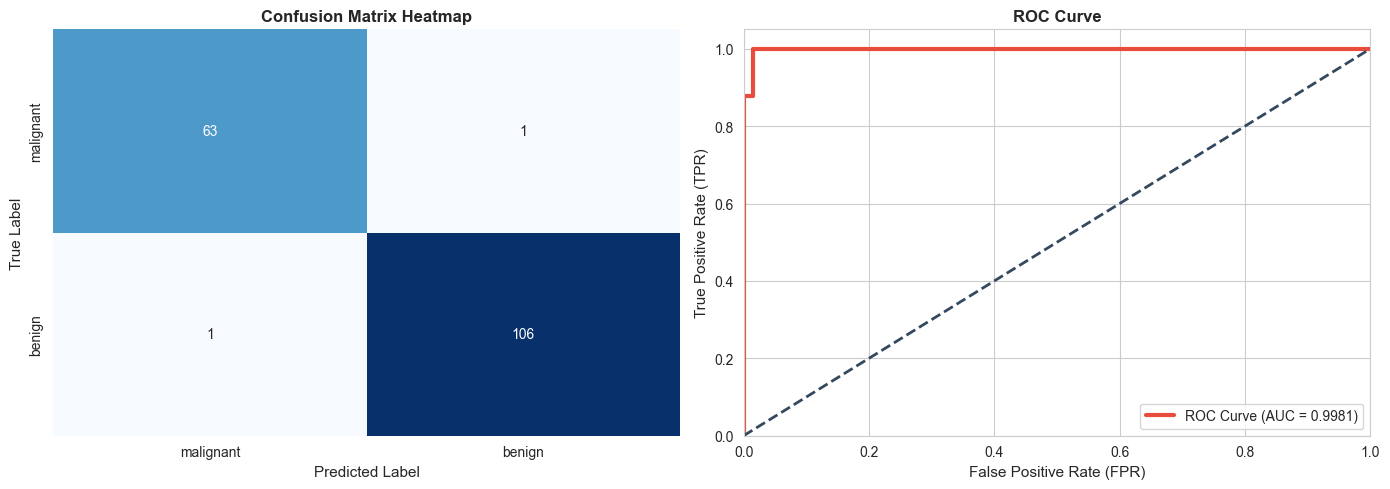

In [11]:
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title('Confusion Matrix Heatmap', fontsize=12, fontweight='bold')

# 2. ROC Curve
axes[1].plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#34495e', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

--- 
## 5. Multiclass Strategy & Decision Boundaries

For classification involving more than two classes, we can generalize binary logistic regression using two main strategies:
1. **One-vs-Rest (OvR)**: Fits one classifier per class. The class with the highest confidence/probability wins.
2. **One-vs-One (OvO)**: Fits a binary classifier for every unique pair of classes ($N(N-1)/2$ models).

### 🗺️ Visualizing the Probabilistic Decision Boundary
Let's select two features to train a visual classifier and plot the boundary regions.

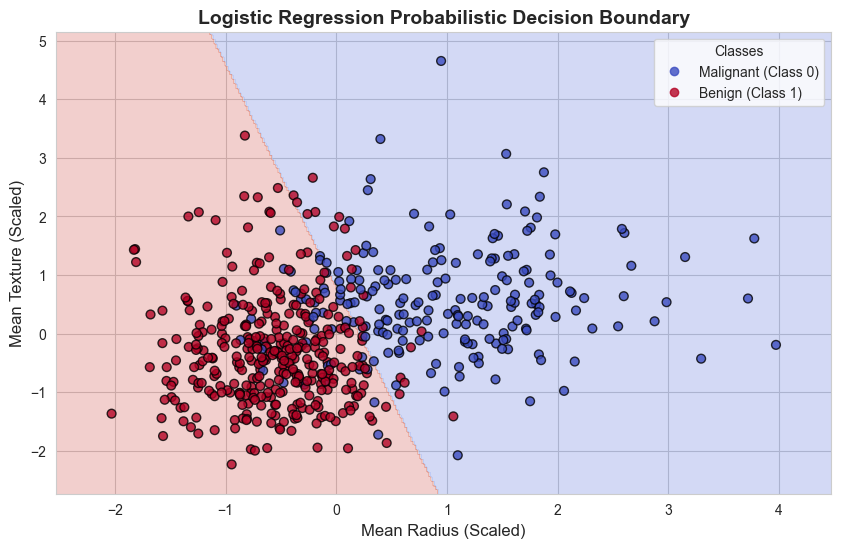

In [12]:
# Train on two features for visual 2D projection: mean radius and mean texture
features_to_plot = ['mean radius', 'mean texture']
X_vis = X_cancer[features_to_plot].values
y_vis = y_cancer

# Scale to uniform distribution
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Fit Logistic Regression
log_reg_vis = LogisticRegression().fit(X_vis_scaled, y_vis)

# Create coordinate meshgrid grid
x_min, x_max = X_vis_scaled[:, 0].min() - 0.5, X_vis_scaled[:, 0].max() + 0.5
y_min, y_max = X_vis_scaled[:, 1].min() - 0.5, X_vis_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), 
                     np.arange(y_min, y_max, 0.02))

# Predict mesh class predictions
grid_preds = log_reg_vis.predict(np.c_[xx.ravel(), yy.ravel()])
grid_preds = grid_preds.reshape(xx.shape)

# Plot contour regions
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, grid_preds, alpha=0.25, cmap='coolwarm')
scatter = plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, 
            cmap='coolwarm', alpha=0.8, edgecolors='k', s=40)
plt.xlabel('Mean Radius (Scaled)', fontsize=12)
plt.ylabel('Mean Texture (Scaled)', fontsize=12)
plt.title('Logistic Regression Probabilistic Decision Boundary', fontsize=14, fontweight='bold')

# Set legend labels
handles, labels = scatter.legend_elements()
plt.legend(handles, ['Malignant (Class 0)', 'Benign (Class 1)'], title="Classes", frameon=True, facecolor='white')
plt.show()

--- 
## 6. Model Cheatsheet & Summary Table

| Algorithm | Primary Type | Penalty / Cost Function | Core Hyperparameters | Strengths | Weaknesses |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Simple Linear Regression** | Regression | Ordinary Least Squares (OLS) / MSE | None | Extremely simple, highly interpretable, fast. | Overly simplistic, highly sensitive to outliers. |
| **Multiple Linear Regression** | Regression | OLS / MSE | None | Models complex feature dependencies. | Prone to overfitting under high feature dimensions. |
| **Ridge Regression ($L_2$)** | Regression | $\text{MSE} + \alpha \sum \beta^2$ | `alpha` | Prevents overfitting, excels with multicollinearity. | Does not exclude features (no automated sparsity). |
| **Lasso Regression ($L_1$)** | Regression | $\text{MSE} + \alpha \sum \|\beta\|$ | `alpha` | Prunes redundant features (sparsity), fast inference. | Unstable feature selection under heavy multicollinearity. |
| **ElasticNet** | Regression | Linear combination of $L_1$ & $L_2$ | `alpha`, `l1_ratio` | Best of both worlds, robust under multicollinearity. | Double hyperparameter tuning overhead. |
| **Logistic Regression** | Classification | Binary Cross Entropy (Log Loss) | `C` (inverse alpha), `penalty` | Fast, outputs actual class probabilities, interpretable. | Assumes linear decision boundary; easily underfits complex shapes. |